<a href="https://colab.research.google.com/github/Aman2000102/DeepLearning/blob/main/VGG16_binarycrossentropy_focalloss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import shutil
import random


In [ ]:
# Path to the folder
path = "/content/drive/MyDrive/Colab Notebooks/covid19normalpneumonia-ct-images"
# Class directories within the zip
classesPath = ['Normal_CT', 'pneumonia_CT']

# Split ratio
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2


# Create a dictionary to hold the number of files in each class
class_file_counts = {}

# First, gather the number of files in each class to find the minority class
for cls in classesPath:
    src = os.path.join(path, cls)
    allFileNames = os.listdir(src)
    class_file_counts[cls] = len(allFileNames)

# Find the minimum file count across all classes (the minority class)
min_files = min(class_file_counts.values())

# Ensure the output directories exist
for cls in classesPath:
    os.makedirs(os.path.join('./train/', cls), exist_ok=True)
    os.makedirs(os.path.join('./val/', cls), exist_ok=True)
    os.makedirs(os.path.join('./test/', cls), exist_ok=True)

    # Define the source path for class images
    src = os.path.join(path, cls)

    # Get list of all image file names in the class directory
    allFileNames = os.listdir(src)
    np.random.shuffle(allFileNames)  # Shuffle the file list to ensure randomness

    # Limit the file count to match the minority class
    balanced_FileNames = allFileNames[:min_files]  # Undersample to match the minority class

    # Calculate the split sizes
    total_files = len(balanced_FileNames)
    train_count = int(train_ratio * total_files)
    val_count = int(val_ratio * total_files)
    test_count = total_files - train_count - val_count  # Remaining files go to the test set

    # Split the filenames into training, validation, and test sets
    train_FileNames = balanced_FileNames[:train_count]
    val_FileNames = balanced_FileNames[train_count:train_count + val_count]
    test_FileNames = balanced_FileNames[train_count + val_count:]

    # Print statistics for each class
    print(f'Total {cls} after balancing: {total_files}')
    print(f'Training: {len(train_FileNames)}')
    print(f'Validation: {len(val_FileNames)}')
    print(f'Testing: {len(test_FileNames)}\n')

    # Copy files to their respective directories
    for name in train_FileNames:
        shutil.copy(os.path.join(src, name), os.path.join('./train/', cls))

    for name in val_FileNames:
        shutil.copy(os.path.join(src, name), os.path.join('./val/', cls))

    for name in test_FileNames:
        shutil.copy(os.path.join(src, name), os.path.join('./test/', cls))


Total Normal_CT after balancing: 2119
Training: 1271
Validation: 423
Testing: 425

Total pneumonia_CT after balancing: 2119
Training: 1271
Validation: 423
Testing: 425



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths to directories
train_dir = 'train'
val_dir = 'val'
test_dir = 'test'

# Stronger Data Augmentation (to prevent overfitting)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)



train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

Found 2542 images belonging to 2 classes.
Found 846 images belonging to 2 classes.
Found 850 images belonging to 2 classes.


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D, Conv2D,
    BatchNormalization, Multiply, Reshape, Input, Softmax
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow.keras.backend as K

# Hybrid BCE + Focal loss
def hybrid_bce_focal(gamma=2.0, alpha=0.25, focal_weight=0.6):
    bce = tf.keras.losses.BinaryCrossentropy()

    def focal_loss(y_true, y_pred):
        y_true_f = K.cast(y_true, dtype='float32')
        y_pred_f = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())

        pt = tf.where(K.equal(y_true_f, 1), y_pred_f, 1 - y_pred_f)
        loss = -alpha * K.pow(1. - pt, gamma) * K.log(pt)
        return K.mean(loss)

    def loss(y_true, y_pred):
        bce_loss = bce(y_true, y_pred)
        focal = focal_loss(y_true, y_pred)
        return focal_weight * focal + (1 - focal_weight) * bce_loss

    return loss

# -------------------------------
# Squeeze-and-Excitation Block
def squeeze_excite_block(input_tensor, ratio=16):
    filters = input_tensor.shape[-1]
    se = GlobalAveragePooling2D()(input_tensor)
    se = Dense(filters // ratio, activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)
    se = Reshape((1, 1, filters))(se)
    return Multiply()([input_tensor, se])

# -------------------------------
# Assume `train_generator`, `val_generator`, `test_generator` are already defined
# Compute class weights
X_train_full, y_train_full = [], []
for i in range(len(train_generator)):
    X_batch, y_batch = train_generator[i]
    X_train_full.append(X_batch)
    y_train_full.append(y_batch)
    if len(X_train_full) * 16 >= train_generator.n:
        break
X_train_full = np.concatenate(X_train_full)
y_train_full = np.concatenate(y_train_full)

X_train, _, y_train, _ = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)
class_weights_dict = dict(enumerate(compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)))

# -------------------------------
# VGG16 Model with Squeeze-and-Excitation
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
for layer in base_model.layers[-100:]:  # freeze most layers
    layer.trainable = True

x = base_model.output
x = squeeze_excite_block(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001))(x)

model = Model(inputs=base_model.input, outputs=output)

# -------------------------------
# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=hybrid_bce_focal(alpha=0.25, gamma=2.0, focal_weight=0.6),
              metrics=['accuracy'])

# -------------------------------
# Callbacks
early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=5, min_lr=1e-7)

# -------------------------------
# Train model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)

# -------------------------------
# Validation evaluation
val_preds = (model.predict(val_generator) > 0.5).astype(int)
val_labels = val_generator.classes
print("Validation:",
      f"Accuracy: {accuracy_score(val_labels, val_preds)}",
      f"Precision: {precision_score(val_labels, val_preds)}",
      f"Recall: {recall_score(val_labels, val_preds)}",
      f"F1: {f1_score(val_labels, val_preds)}")

# -------------------------------
# Test evaluation
X_test_full, y_test_full = [], []
for i in range(len(test_generator)):
    X_batch, y_batch = test_generator[i]
    X_test_full.append(X_batch)
    y_test_full.append(y_batch)
    if len(X_test_full) * 16 >= test_generator.n:
        break
X_test_full = np.concatenate(X_test_full)
y_test_full = np.concatenate(y_test_full)

test_preds = (model.predict(X_test_full) > 0.5).astype(int)
print("Test:",
      f"Accuracy: {accuracy_score(y_test_full, test_preds)}",
      f"Precision: {precision_score(y_test_full, test_preds)}",
      f"Recall: {recall_score(y_test_full, test_preds)}",
      f"F1: {f1_score(y_test_full, test_preds)}")


Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 31s 174ms/step - accuracy: 0.6279 - loss: 0.2802 - val_accuracy: 0.5567 - val_loss: 0.5515 - learning_rate: 1.0000e-04
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 19s 148ms/step - accuracy: 0.8019 - loss: 0.1912 - val_accuracy: 0.5378 - val_loss: 0.8189 - learning_rate: 1.0000e-04
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.8948 - loss: 0.1234 - val_accuracy: 0.5012 - val_loss: 0.8341 - learning_rate: 1.0000e-04
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 18s 127ms/step - accuracy: 0.8999 - loss: 0.1152 - val_accuracy: 0.6702 - val_loss: 0.3411 - learning_rate: 1.0000e-04
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 21s 134ms/step - accuracy: 0.9158 - loss: 0.0920 - val_accuracy: 0.9338 - val_loss: 0.0834 - learning_rate: 1.0000e-04
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 20s 128ms/step - accuracy: 0.9406 - loss: 0.0708 - val_accuracy: 0.5000 - val_loss: 2.2477 - learning_rate: 1.0000e-04
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 21s 13

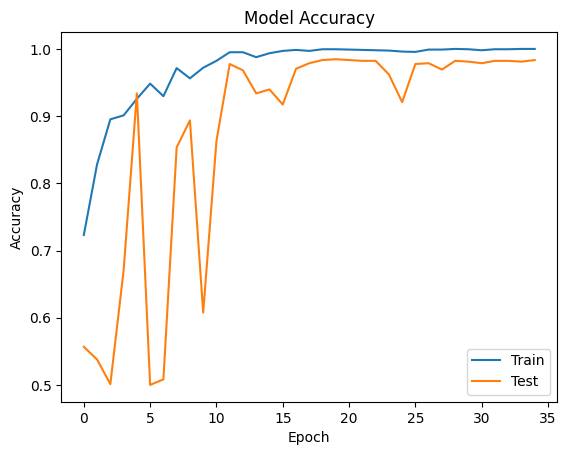

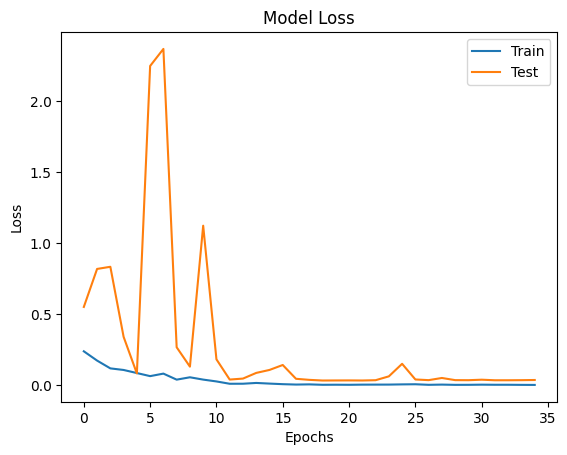

In [ ]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'])
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'])
plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step


<Figure size 800x600 with 0 Axes>

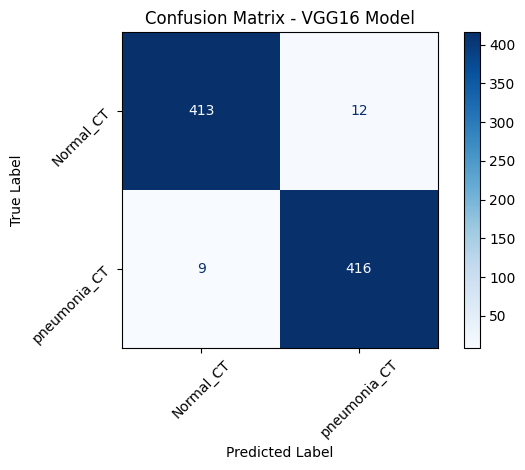

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluate model on test data
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).ravel()  # Convert probabilities to class labels (0 or 1)

# True labels
y_true = test_generator.classes  # Assuming test_generator has the true labels

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - VGG16 Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
model.save('VGG16_binarycrossentropy_focalloss.h5')

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_58']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
<ipython-input-10-39e1b00a3b59>:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap(cmap)


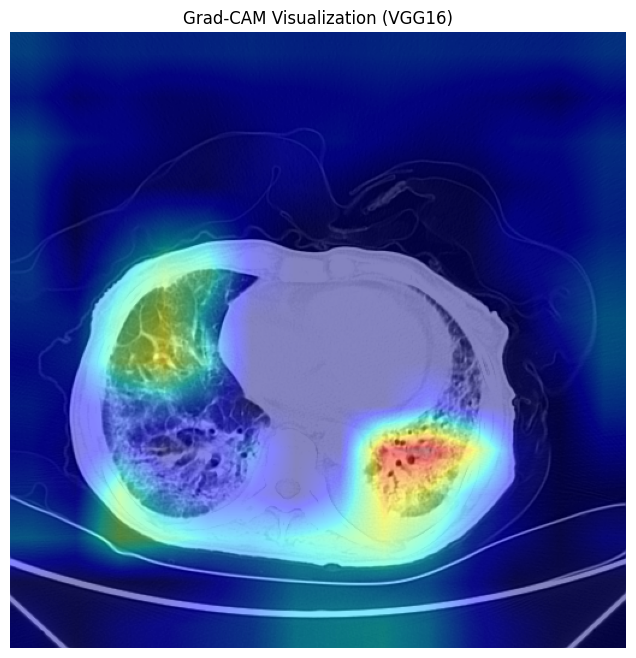

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
import matplotlib.pyplot as plt

# Load the VGG16 model
model = VGG16(weights="imagenet")

# Function to preprocess input image
def preprocess_image(img_path, target_size=(224,224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

# Grad-CAM function
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Compute the gradients of the top predicted class with respect to the output feature map
    grads = tape.gradient(class_channel, conv_outputs)

    # Compute the mean intensity of the gradients for each feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each feature map by its corresponding gradient intensity
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    # Apply ReLU to the heatmap and normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap + tf.keras.backend.epsilon())
    return heatmap.numpy()

# Function to overlay the heatmap on the original image
def overlay_heatmap(heatmap, img_path, alpha=0.4, cmap="jet"):
    img = image.load_img(img_path)
    img = image.img_to_array(img)

    # Resize heatmap to match image dimensions
    heatmap = np.uint8(255 * heatmap)
    heatmap = tf.image.resize(heatmap[..., np.newaxis], (img.shape[0], img.shape[1])).numpy()
    heatmap = heatmap[:, :, 0]

    # Apply colormap
    jet = plt.cm.get_cmap(cmap)
    colored_heatmap = jet(heatmap / 255.0)[:, :, :3]
    colored_heatmap = np.uint8(255 * colored_heatmap)

    # Overlay the heatmap on the image
    superimposed_img = img * (1 - alpha) + colored_heatmap * alpha
    superimposed_img = np.clip(superimposed_img, 0, 255).astype("uint8")
    return tf.keras.preprocessing.image.array_to_img(superimposed_img)

# Test with an example image
img_path = "/content/test/pneumonia_CT/307 (44).jpg"
img_array = preprocess_image(img_path)

# Get Grad-CAM heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="block5_conv3")

# Overlay heatmap on image
superimposed_img = overlay_heatmap(heatmap, img_path)

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.axis("off")
plt.title("Grad-CAM Visualization (VGG16)")
plt.show()

<ipython-input-10-39e1b00a3b59>:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap(cmap)


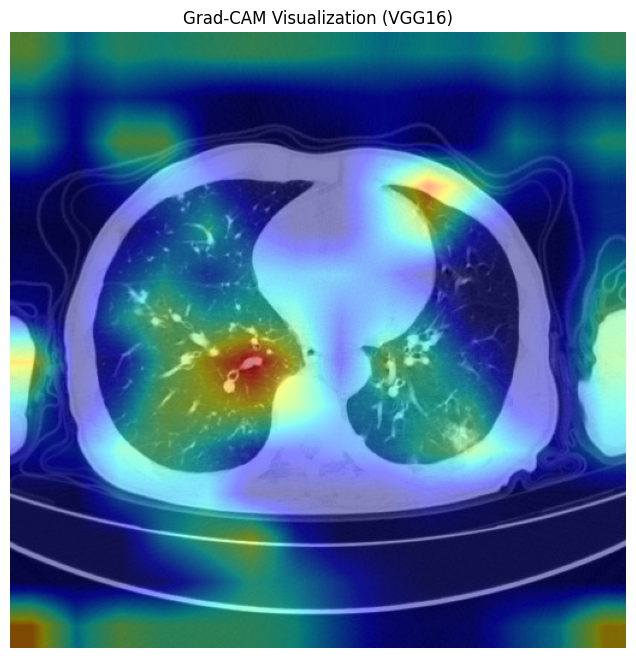

In [ ]:
# Test with an example image
img_path = "/content/test/pneumonia_CT/325 (89).jpg"
img_array = preprocess_image(img_path)

# Get Grad-CAM heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="block5_conv3")

# Overlay heatmap on image
superimposed_img = overlay_heatmap(heatmap, img_path)

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.axis("off")
plt.title("Grad-CAM Visualization (VGG16)")
plt.show()

<ipython-input-10-39e1b00a3b59>:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap(cmap)


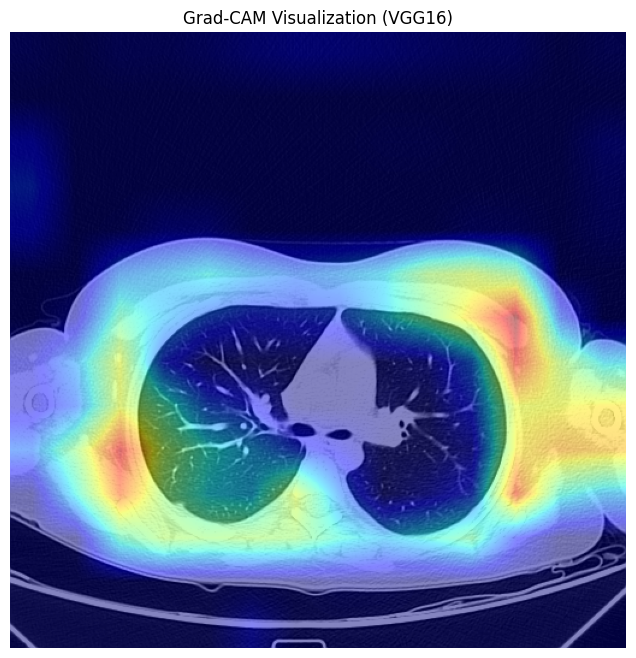

In [ ]:
# Test with an example image
img_path = "/content/test/Normal_CT/325877 (39).jpg"
img_array = preprocess_image(img_path)

# Get Grad-CAM heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="block5_conv3")

# Overlay heatmap on image
superimposed_img = overlay_heatmap(heatmap, img_path)

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.axis("off")
plt.title("Grad-CAM Visualization (VGG16)")
plt.show()

<ipython-input-10-39e1b00a3b59>:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap(cmap)


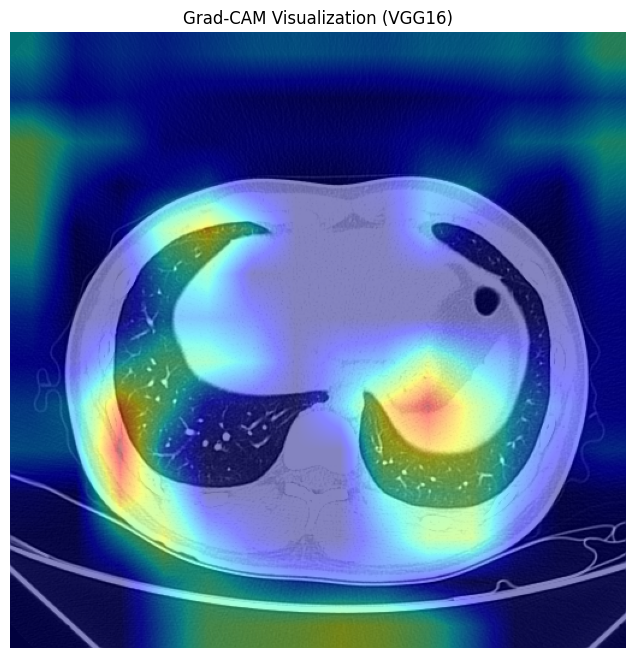

In [ ]:
# Test with an example image
img_path = "/content/test/Normal_CT/ddd4d (16).jpg"
img_array = preprocess_image(img_path)

# Get Grad-CAM heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="block5_conv3")

# Overlay heatmap on image
superimposed_img = overlay_heatmap(heatmap, img_path)

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.axis("off")
plt.title("Grad-CAM Visualization (VGG16)")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 50s 50s/step
Predicted class index: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step


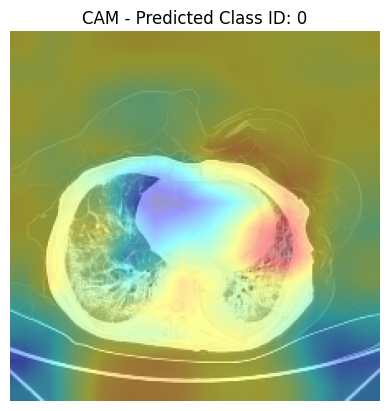

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

# Step 1: Load base VGG16 without top
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Step 2: Add GAP and final Dense layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(1, activation='sigmoid')(x)  # 1000 for ImageNet

# Final model
model = Model(inputs=base_model.input, outputs=predictions)

# Step 3: Load and preprocess image
img_path = '/content/test/pneumonia_CT/307 (44).jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)
img_preprocessed = preprocess_input(img_batch)

# Step 4: Make prediction
preds = model.predict(img_preprocessed)
pred_class = np.argmax(preds[0])
print("Predicted class index:", pred_class)

# Step 5: Get weights of Dense layer
final_dense = model.get_layer(index=-1)  # last layer
class_weights = final_dense.get_weights()[0]  # shape: (num_features, num_classes)

# Step 6: Get last conv layer output
gap_model = Model(inputs=model.input, outputs=base_model.get_layer("block5_conv3").output)
conv_output = gap_model.predict(img_preprocessed)[0]  # shape: (14, 14, 512)

# Step 7: Compute CAM
cam = np.dot(conv_output, class_weights[:, pred_class])  # shape: (14, 14)

# Normalize
cam -= np.min(cam)
cam /= np.max(cam)
cam = cv2.resize(cam, (224, 224))
heatmap = np.uint8(255 * cam)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Superimpose
img_orig = cv2.imread(img_path)
img_orig = cv2.resize(img_orig, (224, 224))
superimposed_img = cv2.addWeighted(img_orig, 0.6, heatmap_color, 0.4, 0)

# Show result
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title(f"CAM - Predicted Class ID: {pred_class}")
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
Predicted class index: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step


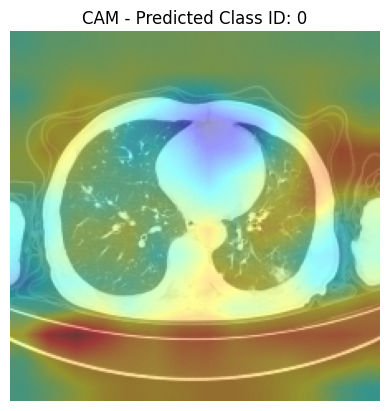

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

# Step 1: Load base VGG16 without top
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Step 2: Add GAP and final Dense layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(1, activation='sigmoid')(x)  # 1000 for ImageNet

# Final model
model = Model(inputs=base_model.input, outputs=predictions)

# Step 3: Load and preprocess image
img_path = '/content/test/pneumonia_CT/325 (89).jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)
img_preprocessed = preprocess_input(img_batch)

# Step 4: Make prediction
preds = model.predict(img_preprocessed)
pred_class = np.argmax(preds[0])
print("Predicted class index:", pred_class)

# Step 5: Get weights of Dense layer
final_dense = model.get_layer(index=-1)  # last layer
class_weights = final_dense.get_weights()[0]  # shape: (num_features, num_classes)

# Step 6: Get last conv layer output
gap_model = Model(inputs=model.input, outputs=base_model.get_layer("block5_conv3").output)
conv_output = gap_model.predict(img_preprocessed)[0]  # shape: (14, 14, 512)

# Step 7: Compute CAM
cam = np.dot(conv_output, class_weights[:, pred_class])  # shape: (14, 14)

# Normalize
cam -= np.min(cam)
cam /= np.max(cam)
cam = cv2.resize(cam, (224, 224))
heatmap = np.uint8(255 * cam)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Superimpose
img_orig = cv2.imread(img_path)
img_orig = cv2.resize(img_orig, (224, 224))
superimposed_img = cv2.addWeighted(img_orig, 0.6, heatmap_color, 0.4, 0)

# Show result
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title(f"CAM - Predicted Class ID: {pred_class}")
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step
Predicted class index: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step


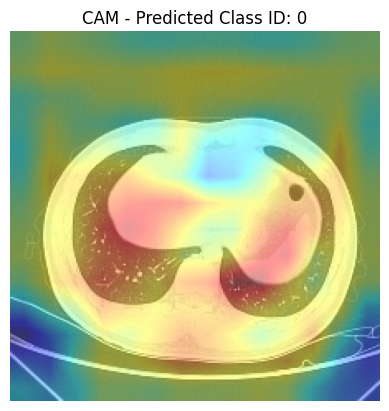

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

# Step 1: Load base VGG16 without top
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Step 2: Add GAP and final Dense layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(1, activation='sigmoid')(x)  # 1000 for ImageNet

# Final model
model = Model(inputs=base_model.input, outputs=predictions)

# Step 3: Load and preprocess image
img_path = '/content/test/Normal_CT/ddd4d (16).jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)
img_preprocessed = preprocess_input(img_batch)

# Step 4: Make prediction
preds = model.predict(img_preprocessed)
pred_class = np.argmax(preds[0])
print("Predicted class index:", pred_class)

# Step 5: Get weights of Dense layer
final_dense = model.get_layer(index=-1)  # last layer
class_weights = final_dense.get_weights()[0]  # shape: (num_features, num_classes)

# Step 6: Get last conv layer output
gap_model = Model(inputs=model.input, outputs=base_model.get_layer("block5_conv3").output)
conv_output = gap_model.predict(img_preprocessed)[0]  # shape: (14, 14, 512)

# Step 7: Compute CAM
cam = np.dot(conv_output, class_weights[:, pred_class])  # shape: (14, 14)

# Normalize
cam -= np.min(cam)
cam /= np.max(cam)
cam = cv2.resize(cam, (224, 224))
heatmap = np.uint8(255 * cam)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Superimpose
img_orig = cv2.imread(img_path)
img_orig = cv2.resize(img_orig, (224, 224))
superimposed_img = cv2.addWeighted(img_orig, 0.6, heatmap_color, 0.4, 0)

# Show result
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title(f"CAM - Predicted Class ID: {pred_class}")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
Predicted class index: 809
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step


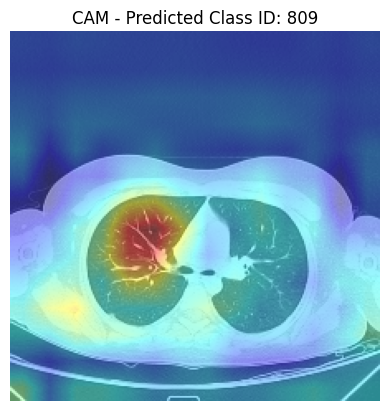

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

# Step 1: Load base VGG16 without top
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Step 2: Add GAP and final Dense layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(1000, activation='softmax')(x)  # 1000 for ImageNet

# Final model
model = Model(inputs=base_model.input, outputs=predictions)

# Step 3: Load and preprocess image
img_path = '/content/test/Normal_CT/325877 (39).jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)
img_preprocessed = preprocess_input(img_batch)

# Step 4: Make prediction
preds = model.predict(img_preprocessed)
pred_class = np.argmax(preds[0])
print("Predicted class index:", pred_class)

# Step 5: Get weights of Dense layer
final_dense = model.get_layer(index=-1)  # last layer
class_weights = final_dense.get_weights()[0]  # shape: (num_features, num_classes)

# Step 6: Get last conv layer output
gap_model = Model(inputs=model.input, outputs=base_model.get_layer("block5_conv3").output)
conv_output = gap_model.predict(img_preprocessed)[0]  # shape: (14, 14, 512)

# Step 7: Compute CAM
cam = np.dot(conv_output, class_weights[:, pred_class])  # shape: (14, 14)

# Normalize
cam -= np.min(cam)
cam /= np.max(cam)
cam = cv2.resize(cam, (224, 224))
heatmap = np.uint8(255 * cam)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Superimpose
img_orig = cv2.imread(img_path)
img_orig = cv2.resize(img_orig, (224, 224))
superimposed_img = cv2.addWeighted(img_orig, 0.6, heatmap_color, 0.4, 0)

# Show result
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title(f"CAM - Predicted Class ID: {pred_class}")
plt.axis('off')
plt.show()

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=40f9f026900317524b5bdbccb7be8c8496c8769d8a8e948ed789613552e3db68
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Predicted: [('n15075141', 'toilet_tissue', np.float32(0.2783443)), ('n02910353', 'buckle', np.float32(0.15505615)), ('n04259630', 'sombrero', np.float32(0.10138938))]


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1

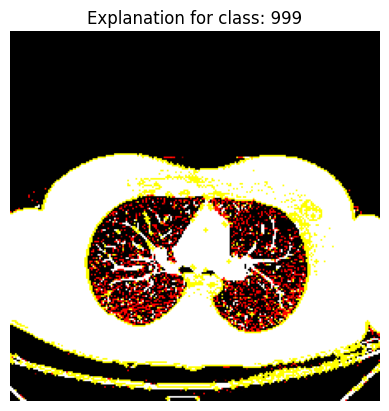

In [ ]:
#Applying LIME XAI technique

import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing import image
from lime import lime_image
from skimage.segmentation import mark_boundaries

def explain_image_with_lime(model, img_path):
    """
    Explains the prediction of a model on a given image using LIME.

    Parameters:
    - model: A pre-trained model that will be used to make predictions.
    - img_path: The path to the image to be explained.

    Returns:
    - None: The function displays the image with LIME explanations.
    """

    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))  # Adjust the target size according to your model
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = model.preprocess_input(img_array)  # Replace with your model's preprocess function if needed

    # Get the model's prediction
    preds = model.predict(img_array)
    print('Predicted:', model.decode_predictions(preds, top=3)[0])  # Adjust this according to your model

    # Initialize LIME image explainer
    explainer = lime_image.LimeImageExplainer()

    # Explain the prediction
    explanation = explainer.explain_instance(
        img_array[0].astype('double'),
        model.predict,
        top_labels=5,
        hide_color=0,
        num_samples=1000
    )

    # Get the explanation for the top predicted label
    top_label = np.argmax(preds)
    temp, mask = explanation.get_image_and_mask(
        top_label,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    # Display the image with boundaries
    plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
    plt.title(f"Explanation for class: {top_label}")
    plt.axis('off')
    plt.show()

# Example usage:
if __name__ == "__main__":
    from tensorflow.keras.applications.vgg16 import VGG16,preprocess_input,decode_predictions
    model = VGG16(weights='imagenet')
    model.preprocess_input = preprocess_input  # Add preprocess and decode functions to the model object
    model.decode_predictions = decode_predictions

    img_path = '/content/test/Normal_CT/325877 (39).jpg'

     # Call the function to explain the image
    explain_image_with_lime(model, img_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted: [('n01930112', 'nematode', np.float32(0.1818827)), ('n03920288', 'Petri_dish', np.float32(0.09092145)), ('n01910747', 'jellyfish', np.float32(0.08344837))]


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

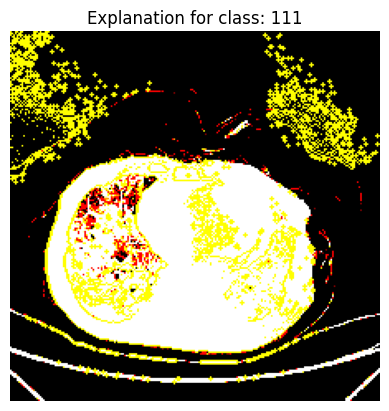

In [ ]:
img_path = '/content/test/pneumonia_CT/307 (44).jpg'

     # Call the function to explain the image
explain_image_with_lime(model, img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted: [('n07930864', 'cup', np.float32(0.15847166)), ('n03950228', 'pitcher', np.float32(0.069933176)), ('n07836838', 'chocolate_sauce', np.float32(0.052155048))]


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

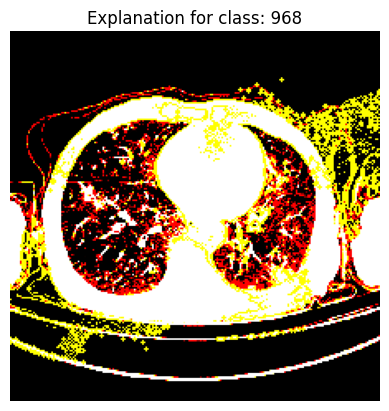

In [ ]:
img_path = '/content/test/pneumonia_CT/325 (89).jpg'

     # Call the function to explain the image
explain_image_with_lime(model, img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted: [('n01930112', 'nematode', np.float32(0.32177928)), ('n03532672', 'hook', np.float32(0.067550205)), ('n02910353', 'buckle', np.float32(0.05798496))]


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

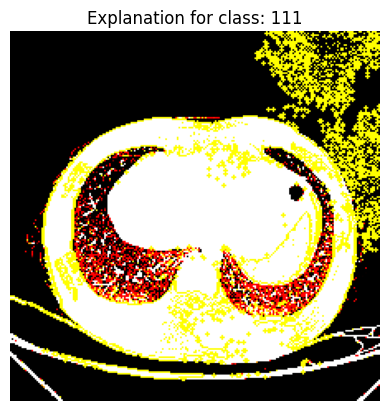

In [ ]:
img_path = '/content/test/Normal_CT/ddd4d (16).jpg'

     # Call the function to explain the image
explain_image_with_lime(model, img_path)